In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
df = pd.read_csv("../data/processed/final_jobs.csv")

print(df.shape)

df.head()

(97682, 16)


,companyname,title,location,minimumsalary,maximumsalary,salary_gap,avg_experience,aggregaterating,reviewscount,salary_band,experience_category,rating_category,salary_band_encoded,experience_encoded,rating_encoded,tagsandskills
0,Orion,Sr. HR Recruiter (NON IT),Kolkata(Chinar Park),200000.0,400000.0,200000.0,3.0,3.7,965.0,Medium,Mid,Good,2,2,2,"Communication,Manpower,Staffing,Convincing Pow..."
1,"Apollo Hospitals International Limited, Ahmedabad",Fire And Safety Officer,"Gandhinagar, Ahmedabad",300000.0,500000.0,200000.0,8.5,4.0,5162.0,Medium,Expert,Good,2,1,2,"Safety Officer Activities,Fire Protection,Fire..."
2,TVS Credit Services Ltd,Opening For Performance Marketing - Chennai,Chennai,0.0,0.0,0.0,15.0,4.2,2892.0,Unknown,Expert,Excellent,5,1,1,"Performance Marketing,User Acquisition,growth ..."
3,GNR Global Services,Medical Billing Executive,"Mohali, Chandigarh, Kharar, Zirakpur",70000.0,200000.0,130000.0,1.5,3.7,965.0,Low,Entry,Good,1,0,2,"Fluent English,Spoken English,Good English Com..."
4,Cadila Pharmaceuticals,Senior Group Product Manager - CNS Therapy,Ahmedabad,800000.0,1800000.0,1000000.0,7.5,3.4,2134.0,Very High,Senior,Good,4,3,2,"Product Marketing,CNS,Product Management,Nephr..."


In [3]:
features = [
    "minimumsalary",
    "maximumsalary",
    "salary_gap",
    "avg_experience",
    "aggregaterating",
    "reviewscount"
]

X = df[features]

y = df["salary_band_encoded"]

print(X.shape)
print(y.shape)

(97682, 6)
(97682,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(78145, 6)
(19537, 6)


In [5]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [6]:
pred = rf.predict(X_test)

pred[:10]

array([1, 5, 0, 1, 5, 5, 5, 2, 5, 0])

In [7]:
acc = accuracy_score(y_test, pred)

print(f"Accuracy : {acc:.4f}")

Accuracy : 0.9999


In [8]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1060
           1       1.00      1.00      1.00      1235
           2       1.00      1.00      1.00      2801
           3       1.00      1.00      1.00       657
           4       1.00      1.00      1.00       892
           5       1.00      1.00      1.00     12892

    accuracy                           1.00     19537
   macro avg       1.00      1.00      1.00     19537
weighted avg       1.00      1.00      1.00     19537



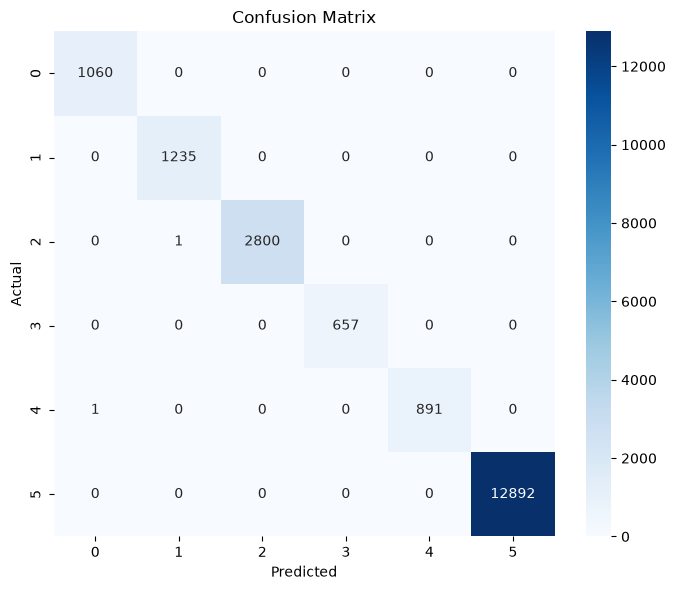

In [9]:
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.tight_layout()

plt.savefig("../outputs/figures/confusion_matrix.png")

plt.show()

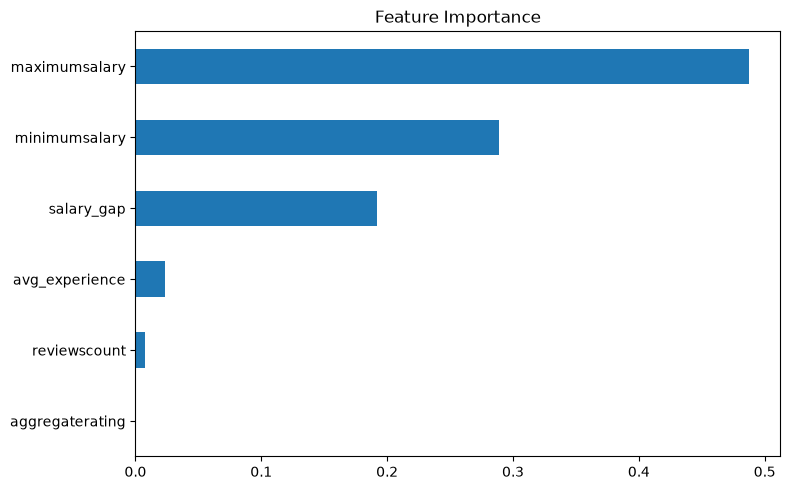

In [10]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance = importance.sort_values()

plt.figure(figsize=(8,5))

importance.plot(kind="barh")

plt.title("Feature Importance")

plt.tight_layout()

plt.savefig("../outputs/figures/feature_importance.png")

plt.show()

In [11]:
import joblib

joblib.dump(
    rf,
    "../outputs/models/random_forest_salary.pkl"
)

print("Model Saved!")

Model Saved!


In [12]:
sample = X.iloc[[0]]

prediction = rf.predict(sample)

print("Predicted Salary Band:", prediction[0])

Predicted Salary Band: 2
